In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys
import pickle as pkl
import pyvisa as visa
import datetime
from scipy.optimize import curve_fit
from collections import defaultdict
from scipy.stats import kurtosis, skew
import pandas as pd
from collections import OrderedDict
from pathlib import Path
import fnmatch
import time
from edes.modules.detection.detection_utils import plot, plot_ax, big_plt_font
from edes.experiments.devices.base import Agilent34461A, RigolDP832A, SiglentSPD3303X_E, SSA3032X_R
from edes.experiments import Experiment
from edes.utils.file_handling import load_exp_config
big_plt_font()

In [2]:
exp = load_exp_config('3layer_trapping_061526')

In [3]:
# rm = visa.ResourceManager()
# instruments = rm.list_resources()

Agilent = Agilent34461A('USB0::2391::7175::MY53200916::0::INSTR')
Vd = RigolDP832A('USB0::6833::3601::DP8B260200018::0::INSTR')
Vg = SiglentSPD3303X_E('TCPIP::192.168.169.101::INSTR')
SSA = SSA3032X_R('TCPIP::192.168.169.161::INSTR')

>>> Connected to Agilent Technologies,34461A,MY53200916,A.01.08-02.22-00.08-00.35-01-01

>>> Connected to RIGOL TECHNOLOGIES,DP832A,DP8B260200018,00.01.19

>>> Connected to Siglent Technologies,SPD3303X-E,SPD3XJEQ6R3773,1.01.01.02.07R2,V3.0

>>> Connected to Siglent Technologies,SSA3032X-R,SSA5PA1Q800415,3.2.2.6.0R10



In [6]:
SSA.set_freq_center(400e6)
SSA.set_freq_span(700e6)
time.sleep(1)
SSA.auto_scale()

In [19]:
Vg.output_off(2)
Vd.output_off(2)

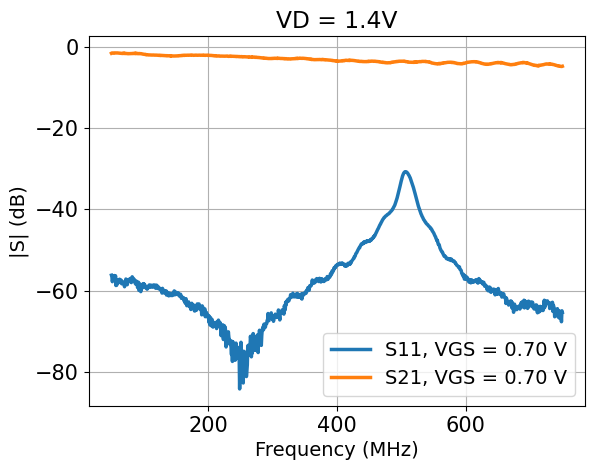

In [18]:
freq, data = SSA.measure_VNA_spectrum(1) 
plot(freq/1e6, data, xlabel='Frequency (MHz)', ylabel='|S| (dB)', title='VD = 1.4V', label=f'S11, VGS = {vgs:.2f} V')
freq, data = SSA.measure_VNA_spectrum(2) 
plot(freq/1e6, data, xlabel='Frequency (MHz)', ylabel='|S| (dB)', title='VD = 1.4V', label=f'S21, VGS = {vgs:.2f} V')

In [18]:
import tqdm
all_data = {} 
for VGS in tqdm.tqdm(np.arange(0, 0.8, 0.02)):
    set_Vg(VGS)
    time.sleep(5)
    SSA.auto_scale()
    time.sleep(1)
    freq, data = SSA.measure_VNA_spectrum(1) 
    all_data[-1*VGS] = data 
    # time.sleep(1)  # Short delay between measurements
Vg.output_off(2)
Vd.output_off(2)

100%|██████████| 40/40 [05:02<00:00,  7.55s/it]


In [20]:
os.makedirs(f'/home/electron/data/experiment_06152026/HEMT', exist_ok=True)
np.savez('/home/electron/data/experiment_06152026/HEMT/gain_biasT_4K_VDD1.npz', all_data=all_data, freq=freq)

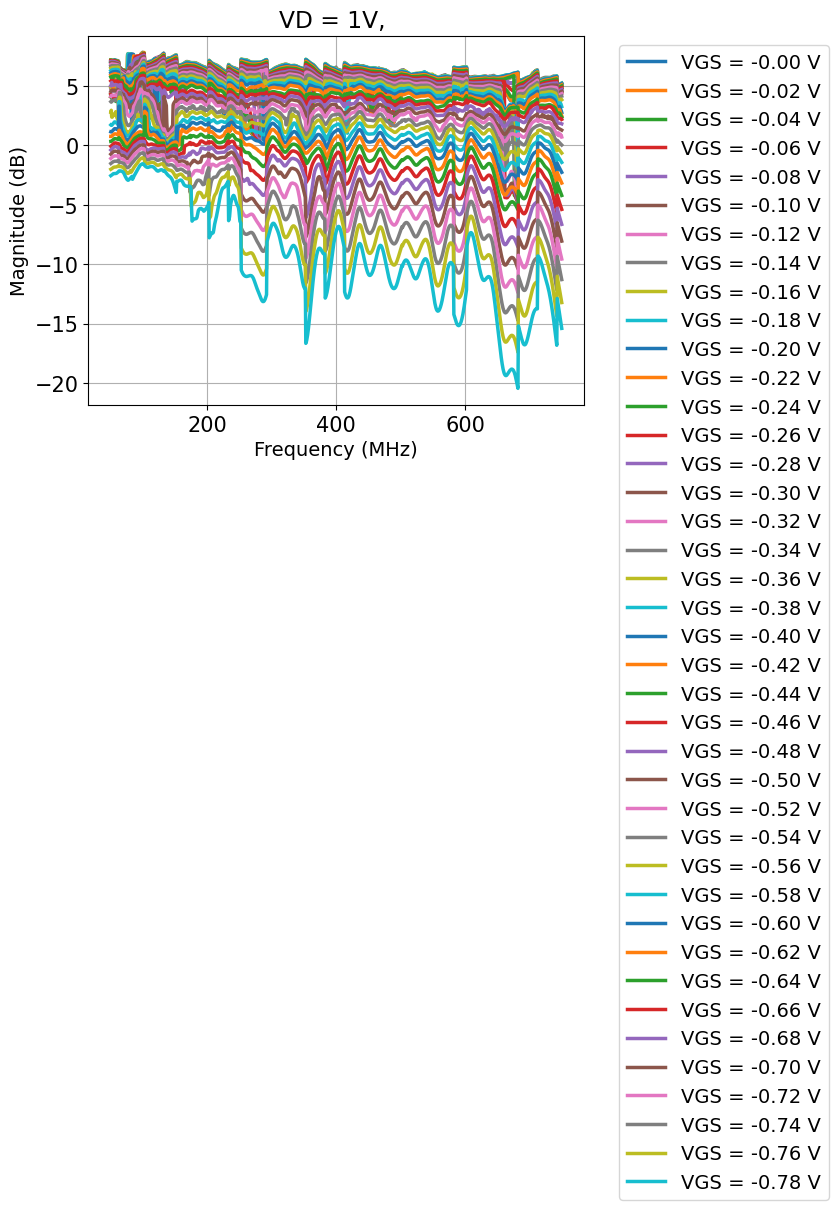

In [23]:
for vgs in all_data: 
    plot(freq/1e6, all_data[vgs], xlabel='Frequency (MHz)', ylabel='Magnitude (dB)', title='VD = 1V, ', label=f'VGS = {vgs:.2f} V')
plt.legend(bbox_to_anchor=(1.05, 1))

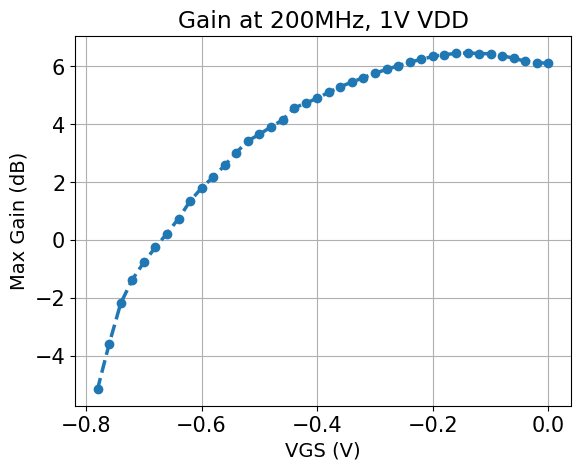

In [25]:
plot(all_data.keys(), [all_data[vgs][np.argmin(abs(freq-200e6))] for vgs in all_data], '.--', xlabel='VGS (V)', ylabel='Max Gain (dB)', title='Gain at 200MHz, 1V VDD')

In [27]:
list(all_data.keys())[np.argmax([all_data[vgs][np.argmin(abs(freq-200e6))] for vgs in all_data])]

np.float64(-0.14)

In [11]:
I = Agilent.read()
I*1e3

0.872250273

In [7]:
set_Vd = lambda V: Vd.set_voltage(2, V) 
set_Vg = lambda V: Vg.set_voltage(2, V)
Vg_on = lambda: Vg.output_on(2) 
Vd_on = lambda: Vd.output_on(2)

In [8]:
set_Vd(1) 
Vd_on()
time.sleep(1)
Vd.measure_voltage(2)

1.0074

In [ ]:
Vd.output_off(2)

In [10]:
set_Vg(0.14) 
Vg.output_on(2)
time.sleep(1) 
Vg.measure_voltage(2)

0.14

In [42]:
Vg.output_off(2)
Vd.output_off(2)

In [13]:
IV = {}
for VGS in np.arange(0.1, 0.8, 0.1):
    set_Vg(VGS)
    Vg_on()
    time.sleep(1)
    vgs = Vg.measure_voltage(2)
    VDS = [] 
    IDS = []
    for V in np.arange(0.1, 1.5, 0.1):
        set_Vd(V)
        Vd_on()
        time.sleep(1)
        vdd = Vd.measure_voltage(2)
        I = Agilent.read()
        VDS.append(vdd) 
        IDS.append(I)
    IV[-1*vgs] = [VDS, IDS]

# Vg.output_off(2)
# Vd.output_off(2)

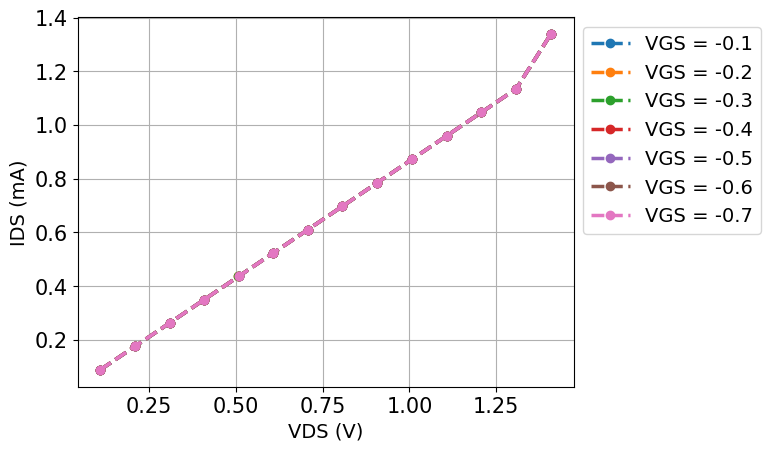

In [14]:
big_plt_font()
for VGS in IV: 
    if 1:
        vds, ids = IV[VGS]
        plot(vds, np.array(ids)*1e3, '.--', label=f'VGS = {VGS}', xlabel='VDS (V)', ylabel='IDS (mA)')
plt.legend(bbox_to_anchor=(1.,1)) 
plt.show()

In [ ]:
ids = [] 
Vgs = np.arange(0.2, 0.6, 0.02)
set_Vd(0.5)
Vd_on()
time.sleep(2)
for VGS in Vgs:
    set_Vg(VGS)
    Vg_on()
    time.sleep(2)
    vgs = Vg.measure_voltage(2)
    IDS = []
    I = Agilent.read()
    ids.append(I) 

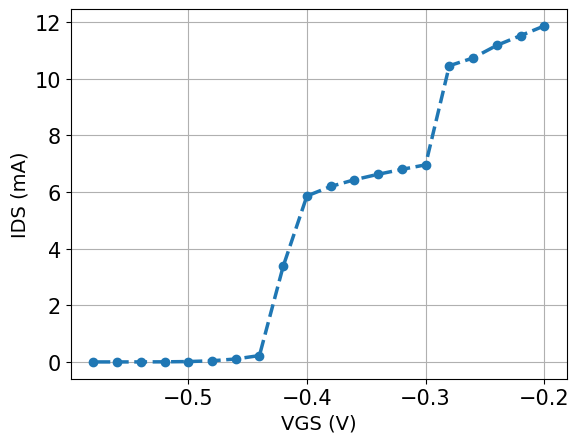

In [ ]:
plot(-Vgs, np.array(ids)*1e3, '.--', xlabel='VGS (V)', ylabel='IDS (mA)')

In [ ]:
os.makedirs(f'/home/electron/data/experiment_06152026/HEMT', exist_ok=True)
np.savez('/home/electron/data/experiment_06152026/HEMT/IV_xihu888_0_4K.npz', IV)

In [ ]:
VDS = [] 
IDS = []
for V in np.arange(0.1, 2.6, 0.1):
    odp.write("INST:NSEL 3")
    odp.write("CURR:PROT 0.05")
    odp.write(f"VOLT {V}")
    odp.write("OUTP ON")
    time.sleep(1)
    vdd = float(odp.query("MEAS:VOLT?"))
    I = float(keithley.query('MEAS:CURR:DC?'))
    VDS.append(vdd) 
    IDS.append(I)
VGS = -0.85
IV[VGS] = [VDS, IDS]

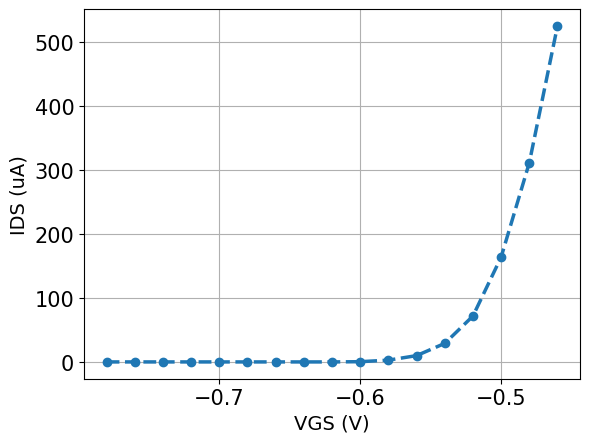

In [ ]:
ID_VG = [] 
VGS_sort = np.sort([_ for _ in IV])
for VGS in VGS_sort: 
    vds, ids = IV[VGS] 
    id_vg = np.array(ids)[np.argmin(abs(np.array(vds) - 1))] 
    ID_VG.append(id_vg) 
ID_VG = np.array(ID_VG)
VGS_sort = np.array(VGS_sort) 
ID_sel_idx = np.where(ID_VG < 1e-3) 
ID_sel = ID_VG[ID_sel_idx] 
VGS_sel = VGS_sort[ID_sel_idx]
plot(VGS_sel, ID_sel*1e6, '.--', xlabel='VGS (V)', ylabel='IDS (uA)')

In [ ]:
ID_sel[0]*1e6

np.float64(7.43841249)

In [ ]:
def get_gm_id(ids, vgs):
    """
    Calculates gm/ID given arrays of IDS and VGS.
    Assumes VGS is sorted/monotonic.
    
    Returns:
        np.array: The gm/ID ratio.
    """
    ids = np.array(ids)
    vgs = np.array(vgs)
    
    # Calculate Transconductance: gm = d(IDS) / d(VGS)
    gm = np.gradient(ids, vgs)
    
    # Calculate gm/ID
    # We use 'where' to handle division by zero safely
    with np.errstate(divide='ignore', invalid='ignore'):
        gm_id = np.where(ids != 0, gm / ids, np.nan)
        
    return gm_id

def get_ro(ids, vds):
    """
    Calculates Output Resistance (ro) given arrays of IDS and VDS.
    Assumes VDS is sorted/monotonic.
    
    Returns:
        np.array: The Output Resistance (ro).
    """
    ids = np.array(ids)
    vds = np.array(vds)
    
    # Calculate Output Conductance: gds = d(IDS) / d(VDS)
    gds = np.gradient(ids, vds)
    
    # Calculate Output Resistance: ro = 1 / gds
    with np.errstate(divide='ignore', invalid='ignore'):
        ro = np.where(gds != 0, 1.0 / gds, np.nan)
        
    return ro

In [ ]:
id_fixedVgs, vd_fixedVds = IV[-0.69]

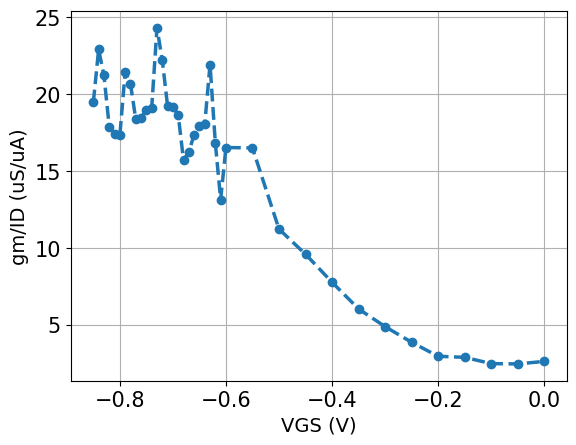

In [ ]:
plot(VGS_sort, get_gm_id(ID_VG, VGS_sort), '.--', xlabel='VGS (V)', ylabel='gm/ID (uS/uA)')

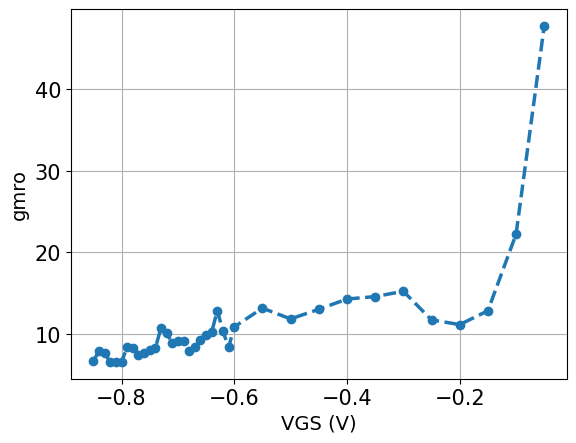

In [ ]:
ro_list = [] 
for vg in VGS_sort: 
    vds, ids = IV[vg] 
    ids, vds = np.array(ids), np.array(vds)
    ro = get_ro(ids, vds) 
    ro_1 = ro[np.argmin(abs(vds-1))] 
    ro_list.append(ro_1) 
    
ro_array = np.array(ro_list) 
plot(VGS_sort[:-1], (get_gm_id(ID_VG, VGS_sort)*ID_VG*ro_array)[:-1], '.--', xlabel='VGS (V)', ylabel='gmro')

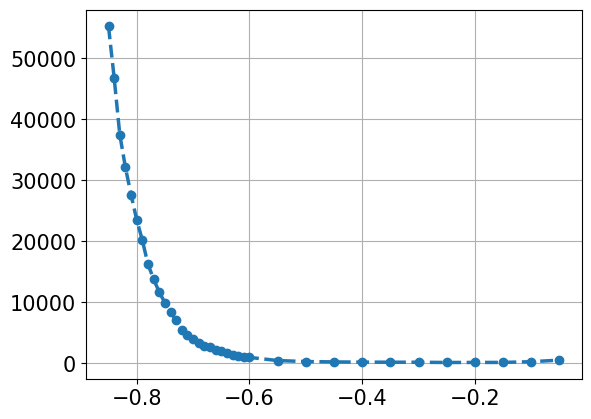

In [ ]:
plot(VGS_sort[:-1], (ro_array)[:-1], '.--')